In [185]:
import numpy as np 
from sklearn.datasets import make_regression

In [186]:
x , y = make_regression(n_samples=4 , n_features=1 , n_informative=1 ,n_targets=1 ,noise=80 , random_state=13)

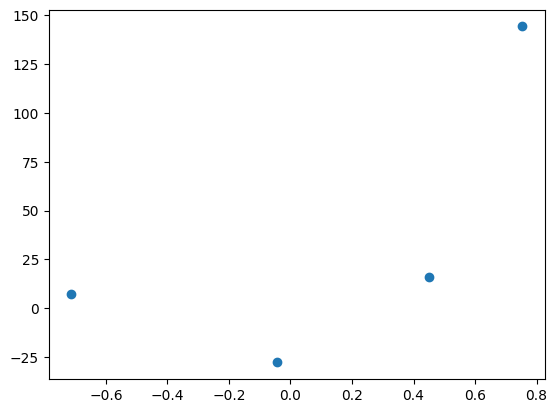

In [187]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show()

In [188]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [189]:
lr.coef_

array([78.35063668])

In [190]:
lr.intercept_

np.float64(26.15963284313262)

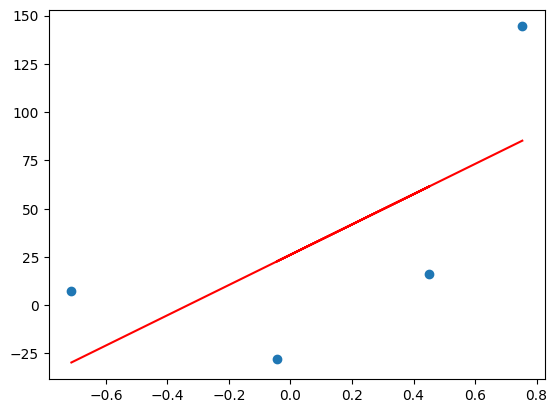

In [191]:
plt.scatter(x,y)
plt.plot(x, lr.predict(x) , color="red")
plt.show()

# Lets apply Gradient Descent assuming slope is constant **m = 78.35**
# and let's assume the starting value for intercept **b = 0**
 

# **Iteration 1**

In [192]:
y_pred = ((78.35 * x) + 0 ).reshape(4)

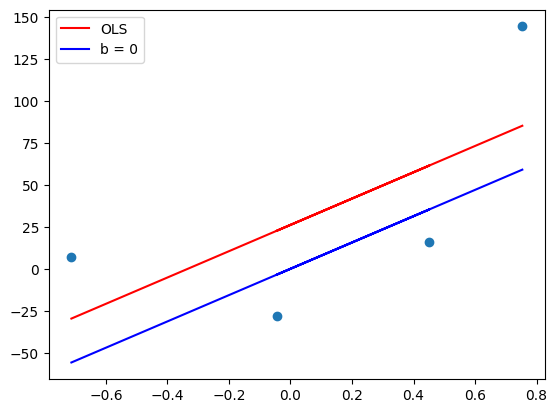

In [193]:
plt.scatter(x,y)
plt.plot(x, lr.predict(x) , color="red" , label='OLS')
plt.plot(x , y_pred , color = "Blue" , label = 'b = 0')
plt.legend()
plt.show()

### We use the ravel() function in NumPy to convert a multi-dimensional array into a flat, one-dimensional array.
### It acts as a quick shortcut to unroll matrices or high-dimensional tensors into a single continuous line of data.

In [194]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y  - m*x.ravel() - b)
loss_slope

np.float64(-209.27763408209216)

In [195]:
learn_rate = 0.1 

step_size = learn_rate * loss_slope
step_size

np.float64(-20.927763408209216)

In [196]:
b1 = b - step_size
b1

np.float64(20.927763408209216)

In [197]:
y_pred1 = (m * x  + b1).reshape(4)

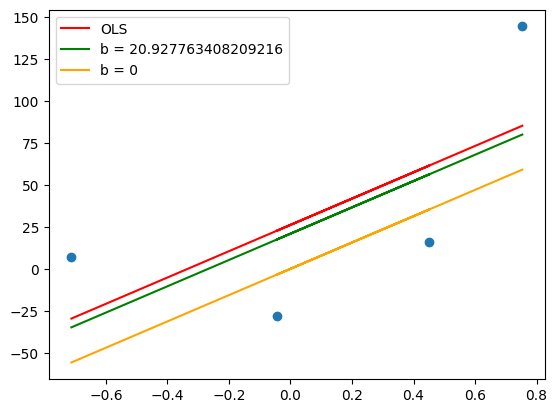

In [198]:
plt.scatter(x,y)
plt.plot(x , lr.predict(x) , color='red' , label = "OLS")
plt.plot(x , y_pred1 , color = 'Green' , label = 'b = {}' .format(b1))
plt.plot(x,y_pred , color = 'Orange' , label = 'b = 0')
plt.legend()
plt.show()

## **Iteration 2**

In [199]:
loss_slope = -2 * np.sum(( y - m*x.ravel() - b1))
loss_slope

np.float64(-41.85552681641843)

In [200]:
step_size = learn_rate * loss_slope

In [201]:
b2 = b1 - step_size
b2

np.float64(25.11331608985106)

In [202]:
y_pred3 = ((m*x) + b2).reshape(4)

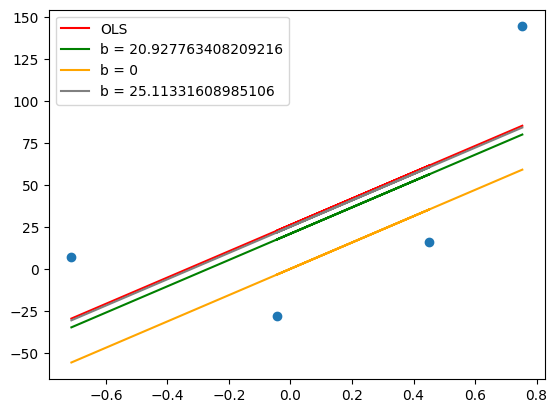

In [203]:
plt.scatter(x,y)
plt.plot(x , lr.predict(x) , color='red' , label = "OLS")
plt.plot(x , y_pred1 , color = 'Green' , label = 'b = {}' .format(b1))
plt.plot(x,y_pred , color = 'Orange' , label = 'b = 0')
plt.plot(x , y_pred3 , color='Grey' , label = 'b = {}' .format(b2))
plt.legend()
plt.show()

## **Iteration 3**

In [204]:
loss_slope = -2 * np.sum(y - m *x.ravel() - b2)

In [205]:
step_size = learn_rate*loss_slope

In [206]:
b3 = b2 - step_size
b3

np.float64(25.95042662617943)

In [207]:
y_pred4 = ((m*x) + b3 )

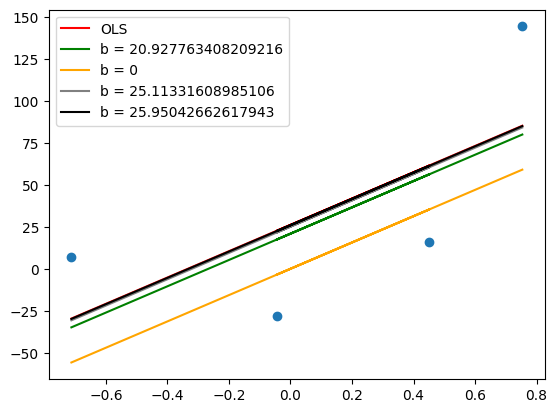

In [208]:
plt.scatter(x,y)
plt.plot(x , lr.predict(x) , color='red' , label = "OLS")
plt.plot(x , y_pred1 , color = 'Green' , label = 'b = {}' .format(b1))
plt.plot(x,y_pred , color = 'Orange' , label = 'b = 0')
plt.plot(x , y_pred3 , color='Grey' , label = 'b = {}' .format(b2))
plt.plot(x , y_pred4 , color = 'black' , label = 'b = {}' .format(b3))
plt.legend()
plt.show()

# **Doing Every thing in loop**

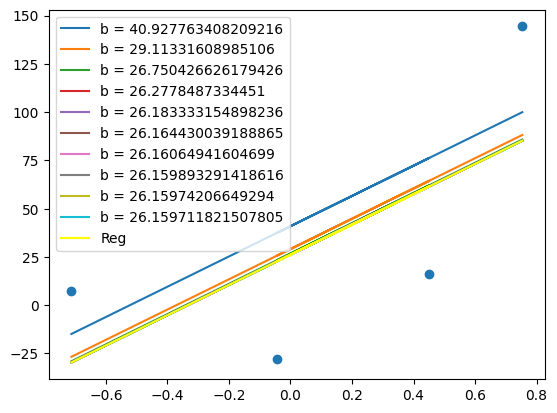

In [210]:
Reg = LinearRegression() # Just use to actual line
Reg.fit(x,y) # Use only to check acutal
b = 100
m = 78.35
lr = 0.1 # if we take leaning rate small then we cannot reach the actual answer beasue we take small steps to check it use lr  = 0.01

epocks =10  # If We take epocks = 100 then we take long steps first and later we stake very small steps

for i in range(epocks) :
    loss_slope = -2 * np.sum(y - m*x.ravel() - b)
    step_size = lr * loss_slope
    b = b - step_size

    y_pred = m*x + b

    
    plt.plot(x , y_pred , label= 'b = {}'.format(b))


plt.scatter(x,y)
plt.plot(x , Reg.predict(x) , label = 'Reg' , color= 'Yellow')
plt.legend()
plt.show()
